# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
import shap
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11383 entries, 0 to 11382
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   CashAndCashEquivalents           11383 non-null  float64       
 1   CurrentDebt                      11383 non-null  float64       
 2   LongTermDebt                     11383 non-null  float64       
 3   TotalDebt                        11383 non-null  float64       
 4   StockholdersEquity               11383 non-null  float64       
 5   TotalAssets                      11383 non-null  float64       
 6   CurrentAssets                    11383 non-null  float64       
 7   CurrentLiabilities               11383 non-null  float64       
 8   OperatingCashFlow_TTM            11383 non-null  float64       
 9   InvestingCashFlow_TTM            11383 non-null  float64       
 10  FinancingCashFlow_TTM            11383 non-null  float64  

## Feature Engineering

In [ ]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [31]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Incluir las variables que tengan baja importancia para reducir el ruido (ej: importance < 0.01)
variables_no_significativas = [
    'RelativeAssets',
    'RelativeRevenue',
    'Revenue_Acceleration',
    'Sector',
    'CapEx_Acceleration',
    'Fcf_Acceleration',
    'CapEx_QoQ',
    'Fcf_QoQ',
    'ReturnOnAssets',
    'Revenue_QoQ',
    'MarketCovariance_Lag1'
]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Posibles labels:
    # 1) Ratios de valuación
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda',    
    # 2) Variables de tamaño (si se usan como label, quitar predictores RelativeAssets y RelativeRevenue para evitar Data Leakage)
    'MarketCap_Log1p',
    'EnterpriseValue_Log1p',

    # Precios (no usar como labels, no tiene sentido predecir precios crudos teniendo multiples tickers)
    'Open',
    'Close',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource'
    ]

# Se define la variable objetivo y las variables predictoras
label = 'EnterpriseValue_Log1p'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.5939


In [32]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.4344 ± 0.0222


In [33]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
0,num__YearsSinceAdded,0.309473
18,cat__Industry,0.200255
14,num__Volume_Lag1_Log1p,0.153754
16,num__DebtToEquity_Log1p,0.048461
1,num__OperatingMargins,0.034818
2,num__ProfitMargins,0.033374
13,num__QuarterlyReturn_Lag1,0.024495
10,num__NetDebtToEbitda,0.021703
6,num__Ebitda_YoY,0.019892
12,num__Ebitda_Acceleration,0.019796


In [34]:
feature_importance_df.tail(6)

,feature,importance
15,num__CapExToRevenue_Log1p,0.015647
9,num__CapEx_YoY,0.015632
4,num__CurrentRatio,0.015559
3,num__ReturnOnEquity,0.012012
8,num__Fcf_YoY,0.011989
11,num__FcfToEbitda,0.010692


In [35]:
# Visualizar distribución de features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,11383.0,15.077220,19.651347,0.000000,0.000000,7.000000,24.000000,69.000000
OperatingMargins,11383.0,0.143864,0.062159,-0.069387,0.099042,0.136987,0.178046,0.416310
ProfitMargins,11383.0,0.098244,0.051914,-0.127108,0.063004,0.091270,0.125391,0.315020
ReturnOnEquity,11383.0,0.287394,0.239362,-0.550311,0.131944,0.211997,0.354230,1.025681
CurrentRatio,11383.0,1.541926,0.552946,0.336404,1.169205,1.435008,1.790954,3.659126
Revenue_YoY,11383.0,0.232747,0.633178,-0.906737,-0.168788,0.094828,0.469112,2.389097
Ebitda_YoY,11383.0,0.511161,1.104922,-1.815358,-0.202101,0.184746,0.807372,3.843102
Ebitda_QoQ,11383.0,0.041498,0.169976,-0.435253,-0.029157,0.002857,0.103437,0.501333
Fcf_YoY,11383.0,0.513368,1.418339,-4.151575,-0.339407,0.088358,0.882936,4.561810
CapEx_YoY,11383.0,-0.468149,1.092065,-3.746815,-0.755859,-0.195846,0.240985,3.798554


## Aplicación del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [36]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train = X.iloc[:-len(df['Ticker'].unique())]  # Todos menos la última fecha de cada ticker
y_train = y.iloc[:-len(df['Ticker'].unique())]
X_test = X.iloc[-len(df['Ticker'].unique()):]   # Solo la última fecha de cada ticker
y_test = y.iloc[-len(df['Ticker'].unique()):]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Consolidar resultados individuales en un DataFrame
resultados_df = pd.DataFrame({
    'Ticker': tickers_test,
    'Predicted': y_pred,
    'Observed': y_test
})

# Calcular el residuo para cada predicción
resultados_df['Residuals'] = resultados_df['Predicted'] - resultados_df['Observed']

# Agrupar por ticker
resultados_agrupados = resultados_df.groupby('Ticker')[['Predicted', 'Observed', 'Residuals']].mean()

# Generar el Cluster sobre el promedio de los residuos
resultados_agrupados['Cluster'] = ['PositiveBias' if r >= 0 else 'NegativeBias' 
                                   for r in resultados_agrupados['Residuals']]

# Visualizar
fig = px.scatter(
    resultados_agrupados, 
    x='Observed', 
    y='Predicted', 
    color='Cluster',
    hover_name=resultados_agrupados.index, 
    labels={'Observed':'Valores Reales', 'Predicted':'Predicciones', 'Cluster':'Sesgo del Modelo'},
    title='Predicciones vs Reales (Agrupado por Ticker)'
)

# Línea de identidad perfecta
min_val = resultados_agrupados['Observed'].min()
max_val = resultados_agrupados['Observed'].max()
fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color='black', dash='dash', width=2))
fig.show()

# Estadísticas por cluster a nivel Ticker
over_mask = resultados_agrupados['Cluster'] == 'PositiveBias'
under_mask = resultados_agrupados['Cluster'] == 'NegativeBias'

print("\nEstadísticas por cluster (a nivel de Ticker):")
print(f"Overprediction: {over_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[over_mask, 'Residuals'].mean():.4f}")
print(f"Underprediction: {under_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[under_mask, 'Residuals'].mean():.4f}")


Estadísticas por cluster (a nivel de Ticker):
Overprediction: 236 tickers, residuo medio global: 0.3535
Underprediction: 245 tickers, residuo medio global: -0.4276


In [37]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker  Predicted  Observed  Residuals      Cluster  PercentError
    HY  23.616647 22.240794   1.375853 PositiveBias      6.186167
  CENT  23.449917 22.138103   1.311813 PositiveBias      5.925591
  COTY  23.902616 22.590979   1.311637 PositiveBias      5.806019
 CMCSA  25.056670 23.778344   1.278327 PositiveBias      5.376013
   TDG  23.937162 22.759512   1.177650 PositiveBias      5.174320


In [38]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,QuarterlyReturn_Lag1,MarketCovariance_Lag1,RelativeAssets,RelativeRevenue,Volume_Lag1_Log1p,CapExToRevenue_Log1p,DebtToEquity_Log1p,QuarterlyVariance_Lag1_Log1p,MarketCap_Log1p,EnterpriseValue_Log1p
0,HY,23.616647,22.240794,1.375853,PositiveBias,6.186167,171.000,228.000,894.000,904.000,...,0.345737,-0.043025,0.000857,0.000987,3.699852,0.008526,0.354565,0.639463,22.332691,22.240794
1,CENT,23.449917,22.138103,1.311813,PositiveBias,5.925591,1523.800,23.690,1192.092,1440.307,...,0.143995,0.027542,0.000517,0.001592,4.080543,0.023593,0.462227,0.590459,21.950244,22.138103
2,COTY,23.902616,22.590979,1.311637,PositiveBias,5.806019,436.700,2.700,3270.500,4297.600,...,-0.329209,-0.007196,0.001033,0.001021,5.602660,0.041525,0.856510,0.103293,21.615460,22.590979
3,CMCSA,25.056670,23.778344,1.278327,PositiveBias,5.376013,3132.000,550.000,5756.000,6903.000,...,0.164481,0.008736,0.002421,0.002476,5.152124,0.110007,0.623514,1.160395,23.582711,23.778344
4,TDG,23.937162,22.759512,1.177650,PositiveBias,5.174320,775.157,541.284,5171.000,1889.524,...,-0.433987,0.009950,0.000625,0.001364,3.265126,0.023935,0.630903,0.461537,22.602338,22.759512


## Explicabilidad del Modelo (SHAP)

In [39]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'WY'

--- Explicación de la predicción para: WY ---


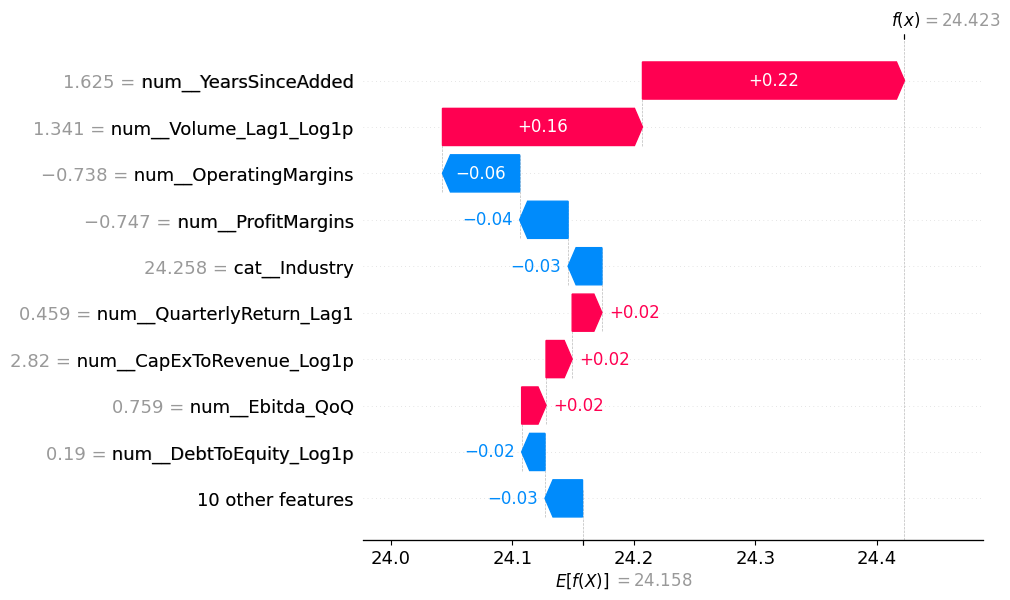

In [40]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [41]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)